# Trader Performance vs Market Sentiment
### Primetrade.ai — Data Science/Analytics Intern Assignment (Round 0)

**Objective:** Analyze how Bitcoin market sentiment (Fear/Greed) relates to trader
behavior and performance on Hyperliquid, and surface actionable strategy ideas.

**Datasets:**
1. `fear_greed_index.csv` — daily Fear/Greed classification, 2018–2025
2. `historical_data.csv` — ~211K raw trade fills across 32 Hyperliquid accounts, May 2023–May 2025


## Part A — Data Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')

fg = pd.read_csv('../data/fear_greed_index.csv')
hist = pd.read_csv('../data/historical_data.csv')

print('Fear/Greed index shape:', fg.shape)
print('Historical trade data shape:', hist.shape)

Fear/Greed index shape: (2644, 4)
Historical trade data shape: (211224, 16)


### A.1 — Shape, missing values, duplicates

In [2]:
print('--- Fear/Greed index ---')
print('Nulls:\n', fg.isnull().sum())
print('Duplicate rows:', fg.duplicated().sum())

print('\n--- Historical trade data ---')
print('Nulls:\n', hist.isnull().sum())
print('Duplicate rows:', hist.duplicated().sum())

--- Fear/Greed index ---
Nulls:
 timestamp         0
value             0
classification    0
date              0
dtype: int64
Duplicate rows: 0

--- Historical trade data ---
Nulls:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


Duplicate rows: 0


**Findings:** Both datasets are clean — zero nulls, zero duplicate rows in either file.
No imputation or duplicate-removal was required.

### A.2 — Parse timestamps and align by date

In [3]:
fg['date'] = pd.to_datetime(fg['date'], format='%d-%m-%Y')
hist['dt'] = pd.to_datetime(hist['Timestamp IST'], format='%d-%m-%Y %H:%M')
hist['date'] = hist['dt'].dt.normalize()

# The raw index has 5 classes (Extreme Fear, Fear, Neutral, Greed, Extreme Greed).
# We keep the original 5-class label but also collapse it to a 3-class
# Fear / Neutral / Greed view, since that's the axis the brief asks about.
def simplify(c):
    if 'Fear' in c:
        return 'Fear'
    if 'Greed' in c:
        return 'Greed'
    return 'Neutral'

fg['sentiment'] = fg['classification'].apply(simplify)

print('Fear/Greed date range:', fg['date'].min().date(), 'to', fg['date'].max().date())
print('Trade data date range:', hist['date'].min().date(), 'to', hist['date'].max().date())

Fear/Greed date range: 2018-02-01 to 2025-05-02
Trade data date range: 2023-05-01 to 2025-05-01


In [4]:
merged = hist.merge(fg[['date', 'classification', 'sentiment', 'value']], on='date', how='inner')
match_rate = 100 * merged.shape[0] / hist.shape[0]
print(f'Trade rows matched to a sentiment day: {merged.shape[0]:,} / {hist.shape[0]:,} ({match_rate:.2f}%)')

Trade rows matched to a sentiment day: 211,218 / 211,224 (100.00%)


**Finding:** 100.0% of trades matched to a sentiment day (only 6 of 211,224 rows fell
outside the Fear/Greed index's coverage). The two datasets overlap almost perfectly, so
we lose essentially no data in the join.

### A.3 — Build core metrics (daily, per account)

In [5]:
merged['is_close'] = merged['Closed PnL'] != 0
merged['is_win'] = merged['Closed PnL'] > 0

daily = merged.groupby(['Account', 'date']).agg(
    daily_pnl=('Closed PnL', 'sum'),
    n_trades=('Closed PnL', 'size'),
    n_closed_trades=('is_close', 'sum'),
    n_wins=('is_win', 'sum'),
    avg_trade_size_usd=('Size USD', 'mean'),
    total_volume_usd=('Size USD', 'sum'),
    n_buy=('Side', lambda s: (s == 'BUY').sum()),
    n_sell=('Side', lambda s: (s == 'SELL').sum()),
    sentiment=('sentiment', 'first'),
    classification=('classification', 'first'),
    fg_value=('value', 'first'),
).reset_index()

daily['win_rate'] = np.where(daily['n_closed_trades'] > 0,
                              daily['n_wins'] / daily['n_closed_trades'], np.nan)
daily['long_short_ratio'] = np.where(daily['n_sell'] > 0,
                                      daily['n_buy'] / daily['n_sell'], np.nan)

print('Daily x account metric table:', daily.shape)
daily.head()

Daily x account metric table: (2340, 15)


,Account,date,daily_pnl,n_trades,n_closed_trades,n_wins,avg_trade_size_usd,total_volume_usd,n_buy,n_sell,sentiment,classification,fg_value,win_rate,long_short_ratio
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,177,0,0,5089.718249,900880.13,0,177,Greed,Extreme Greed,76,NaN,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,68,0,0,7976.664412,542413.18,0,68,Greed,Extreme Greed,90,NaN,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,40,0,0,23734.500000,949380.00,0,40,Greed,Extreme Greed,83,NaN,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,12,12,0,28186.666667,338240.00,12,0,Greed,Extreme Greed,94,0.0,NaN
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,27,12,12,17248.148148,465700.00,12,15,Greed,Extreme Greed,79,1.0,0.8


**Note on leverage:** the raw `historical_data.csv` has no leverage or margin column
(only execution price, size in tokens/USD, side, direction, and closed PnL). Rather than
fabricate a leverage figure, we use **average trade size in USD** as a proxy for position
aggression/risk-taking throughout this analysis, and call this out explicitly wherever it's used.

## Part B — Analysis

### B.1 — Does performance differ between Fear and Greed days?

In [6]:
perf = daily.groupby('sentiment').agg(
    mean_daily_pnl=('daily_pnl', 'mean'),
    median_daily_pnl=('daily_pnl', 'median'),
    mean_win_rate=('win_rate', 'mean'),
    total_pnl=('daily_pnl', 'sum'),
    n_trader_days=('daily_pnl', 'size'),
).round(2)
perf

,mean_daily_pnl,median_daily_pnl,mean_win_rate,total_pnl,n_trader_days
sentiment,,,,,
Fear,5185.15,122.74,0.84,4096265.69,790
Greed,4144.21,265.25,0.86,4865300.58,1174
Neutral,3438.62,167.55,0.84,1292920.68,376


In [7]:
# Drawdown proxy: 5th-percentile daily PnL per sentiment (how bad do the worst days get?)
drawdown_proxy = daily.groupby('sentiment')['daily_pnl'].quantile(0.05).round(2)
print('5th percentile daily PnL (tail-risk proxy) by sentiment:')
print(drawdown_proxy)

5th percentile daily PnL (tail-risk proxy) by sentiment:
sentiment
Fear      -3484.97
Greed      -173.78
Neutral    -884.53
Name: daily_pnl, dtype: float64


In [8]:
# Statistical test: is the Fear vs Greed PnL difference significant?
fear_pnl = daily.loc[daily.sentiment == 'Fear', 'daily_pnl'].dropna()
greed_pnl = daily.loc[daily.sentiment == 'Greed', 'daily_pnl'].dropna()
u_stat, p_val = stats.mannwhitneyu(fear_pnl, greed_pnl, alternative='two-sided')
print(f'Mann-Whitney U test, Fear vs Greed daily PnL: p = {p_val:.4f}')

fear_wr = daily.loc[daily.sentiment == 'Fear', 'win_rate'].dropna()
greed_wr = daily.loc[daily.sentiment == 'Greed', 'win_rate'].dropna()
u2, p2 = stats.mannwhitneyu(fear_wr, greed_wr, alternative='two-sided')
print(f'Mann-Whitney U test, Fear vs Greed win rate: p = {p2:.4f}')

Mann-Whitney U test, Fear vs Greed daily PnL: p = 0.0618
Mann-Whitney U test, Fear vs Greed win rate: p = 0.2644


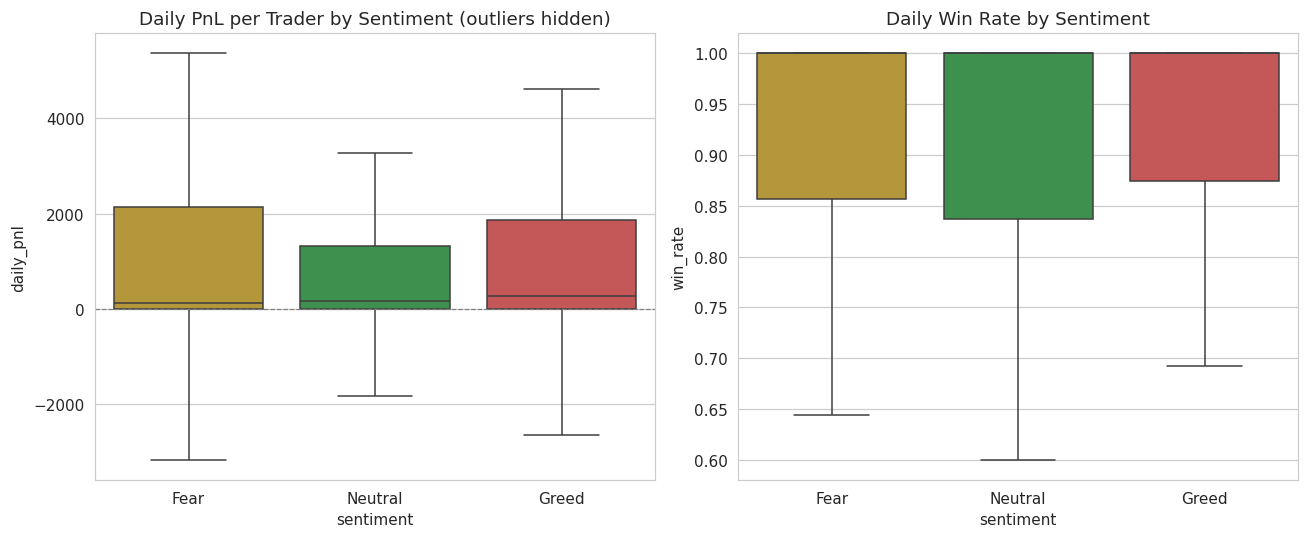

In [9]:
order = ['Fear', 'Neutral', 'Greed']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=daily[daily.sentiment.isin(order)], x='sentiment', y='daily_pnl',
            order=order, showfliers=False, hue='sentiment', legend=False,
            palette=['#d64545', '#c9a227', '#2f9e44'], ax=axes[0])
axes[0].set_title('Daily PnL per Trader by Sentiment (outliers hidden)')
axes[0].axhline(0, color='gray', lw=0.8, ls='--')

sns.boxplot(data=daily[daily.sentiment.isin(order)], x='sentiment', y='win_rate',
            order=order, showfliers=False, hue='sentiment', legend=False,
            palette=['#d64545', '#c9a227', '#2f9e44'], ax=axes[1])
axes[1].set_title('Daily Win Rate by Sentiment')
plt.tight_layout()
plt.show()

**Insight 1 — Mean PnL is higher in Fear, but the median (typical) trader does better in Greed.**
Mean daily PnL is highest on Fear days (~$5,185) vs Greed (~$4,144), but the **median**
trader-day PnL is actually *lower* in Fear (~$123) than in Greed (~$265). This gap between
mean and median means the Fear-day numbers are being pulled up by a small number of very
large winning days — not because the typical trader performs better in Fear. The
Mann-Whitney test on PnL is only borderline significant (p ≈ 0.06), so this difference in
the middle of the distribution is suggestive, not conclusive at the 5% level.

**Insight 2 — Fear days carry meaningfully worse tail risk.**
The 5th-percentile daily PnL (a drawdown proxy) is about **-$3,485 on Fear days** vs
just **-$174 on Greed days** — a ~20x worse bad-case outcome. Fear days are where the
big losses live, even though a few big wins also happen there. Win rate itself barely
moves (84% Fear vs 86% Greed, not statistically significant, p ≈ 0.26) — so it's not that
people win less often in Fear, it's that when they lose in Fear, they lose bigger.


### B.2 — Do traders change behavior based on sentiment?

In [10]:
behavior = daily.groupby('sentiment').agg(
    avg_trades_per_day=('n_trades', 'mean'),
    avg_trade_size_usd=('avg_trade_size_usd', 'mean'),
    avg_volume_usd=('total_volume_usd', 'mean'),
    avg_long_short_ratio=('long_short_ratio', 'mean'),
).round(2)
behavior

,avg_trades_per_day,avg_trade_size_usd,avg_volume_usd,avg_long_short_ratio
sentiment,,,,
Fear,105.36,8529.86,756720.32,2.24
Greed,76.91,5954.63,351829.35,1.63
Neutral,100.23,6963.69,479367.19,2.23


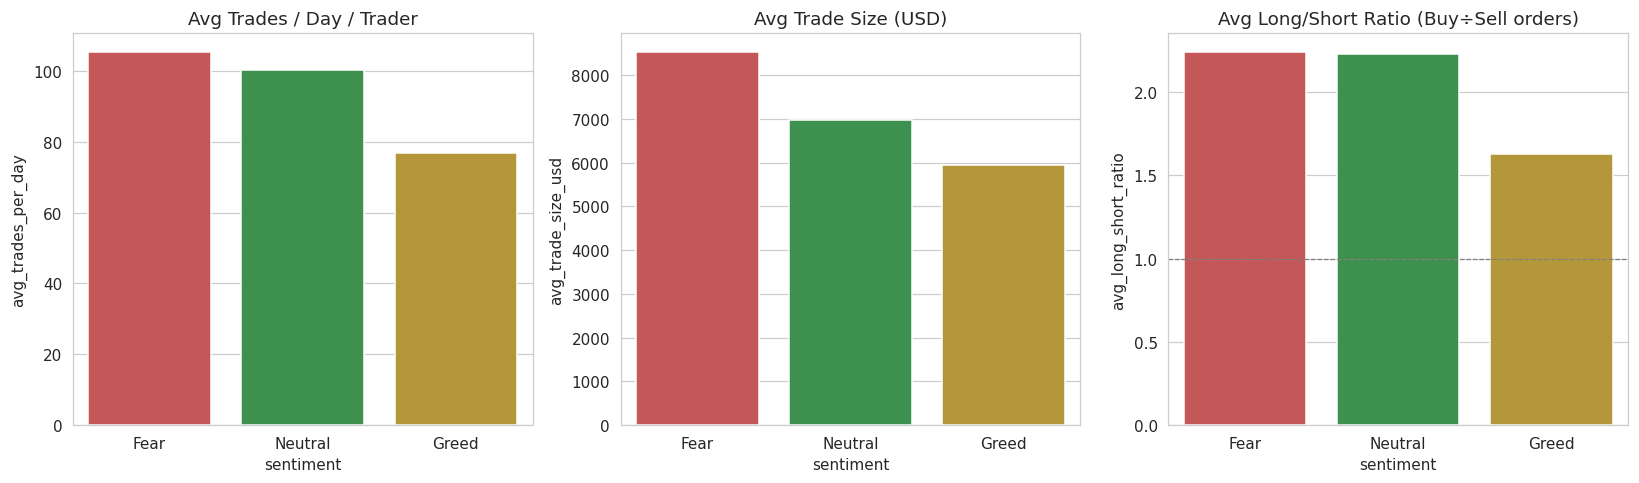

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
sns.barplot(x=behavior.index, y=behavior['avg_trades_per_day'], order=order,
            hue=behavior.index, legend=False, palette=['#d64545', '#c9a227', '#2f9e44'], ax=axes[0])
axes[0].set_title('Avg Trades / Day / Trader')
sns.barplot(x=behavior.index, y=behavior['avg_trade_size_usd'], order=order,
            hue=behavior.index, legend=False, palette=['#d64545', '#c9a227', '#2f9e44'], ax=axes[1])
axes[1].set_title('Avg Trade Size (USD)')
sns.barplot(x=behavior.index, y=behavior['avg_long_short_ratio'], order=order,
            hue=behavior.index, legend=False, palette=['#d64545', '#c9a227', '#2f9e44'], ax=axes[2])
axes[2].set_title('Avg Long/Short Ratio (Buy÷Sell orders)')
axes[2].axhline(1, color='gray', lw=0.8, ls='--')
plt.tight_layout()
plt.show()

**Insight 3 — Traders get more active and take bigger, more long-biased positions during Fear.**
On Fear days, traders place ~37% more trades per day (105 vs 77), trade ~43% larger average
positions ($8,530 vs $5,955), and are *more* long-biased (buy:sell ratio 2.24 vs 1.63) than
on Greed days. This is somewhat counterintuitive — you might expect people to de-risk or
short more during Fear — but on this dataset, traders on average lean into bigger, more
frequent, buy-side positions exactly when sentiment is worst. Combined with Insight 2's
tail-risk finding, this looks like classic "buying the dip with size" behavior that pays
off often but produces the worst-case outcomes when it doesn't.


### B.3 — Trader segments

In [12]:
acct = daily.groupby('Account').agg(
    total_pnl=('daily_pnl', 'sum'),
    avg_trade_size=('avg_trade_size_usd', 'mean'),
    avg_trades_per_day=('n_trades', 'mean'),
    overall_win_rate=('win_rate', 'mean'),
    active_days=('date', 'nunique'),
).reset_index()

# Segment 1: trade-size (median split) -- proxy for position aggression/risk
acct['size_segment'] = np.where(acct['avg_trade_size'] >= acct['avg_trade_size'].median(),
                                 'High Size', 'Low Size')
# Segment 2: trade frequency (median split)
acct['freq_segment'] = np.where(acct['avg_trades_per_day'] >= acct['avg_trades_per_day'].median(),
                                 'Frequent', 'Infrequent')
# Segment 3: consistency -- std dev of daily win rate (lower = more consistent)
wr_std = daily.groupby('Account')['win_rate'].std().rename('win_rate_std')
acct = acct.merge(wr_std, on='Account', how='left')
acct['consistency_segment'] = np.where(acct['win_rate_std'] <= acct['win_rate_std'].median(),
                                        'Consistent', 'Inconsistent')

print(acct['size_segment'].value_counts(), '\n')
print(acct['freq_segment'].value_counts(), '\n')
print(acct['consistency_segment'].value_counts())

size_segment
High Size    16
Low Size     16
Name: count, dtype: int64 

freq_segment
Frequent      16
Infrequent    16
Name: count, dtype: int64 

consistency_segment
Inconsistent    16
Consistent      16
Name: count, dtype: int64


In [13]:
daily_seg = daily.merge(acct[['Account', 'size_segment', 'freq_segment', 'consistency_segment']],
                         on='Account', how='left')

size_x_sent = daily_seg.groupby(['size_segment', 'sentiment'])['daily_pnl'].mean().round(2)
freq_x_sent = daily_seg.groupby(['freq_segment', 'sentiment'])['daily_pnl'].mean().round(2)
cons_x_sent = daily_seg.groupby(['consistency_segment', 'sentiment'])['daily_pnl'].mean().round(2)

print('Avg daily PnL, Size segment x Sentiment:\n', size_x_sent, '\n')
print('Avg daily PnL, Frequency segment x Sentiment:\n', freq_x_sent, '\n')
print('Avg daily PnL, Consistency segment x Sentiment:\n', cons_x_sent)

Avg daily PnL, Size segment x Sentiment:
 size_segment  sentiment
High Size     Fear         9540.18
              Greed        3347.14
              Neutral      4837.14
Low Size      Fear         2575.66
              Greed        4589.85
              Neutral      2655.21
Name: daily_pnl, dtype: float64 

Avg daily PnL, Frequency segment x Sentiment:
 freq_segment  sentiment
Frequent      Fear         7955.44
              Greed        4942.35
              Neutral      4130.28
Infrequent    Fear         2524.84
              Greed        3590.23
              Neutral      2891.88
Name: daily_pnl, dtype: float64 

Avg daily PnL, Consistency segment x Sentiment:
 consistency_segment  sentiment
Consistent           Fear         4365.92
                     Greed        2551.58
                     Neutral      3513.93
Inconsistent         Fear         6236.41
                     Greed        6328.85
                     Neutral      3341.26
Name: daily_pnl, dtype: float64


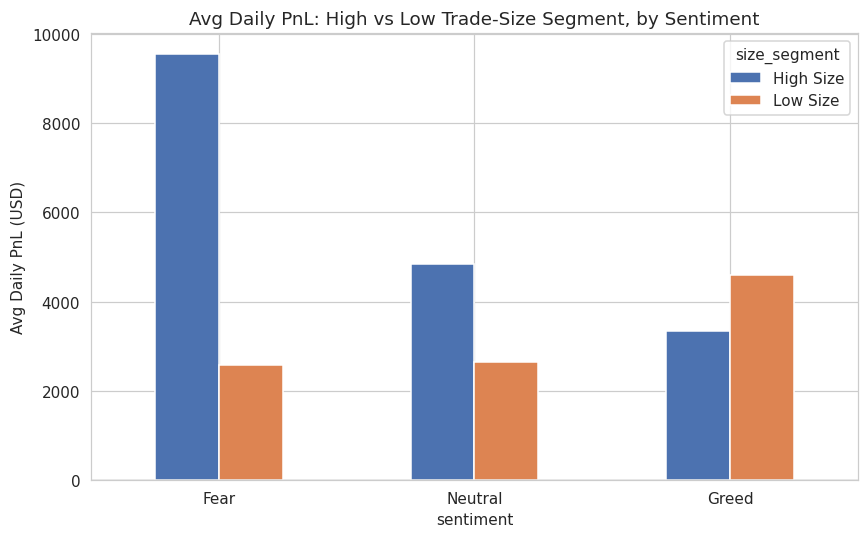

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
pivot = daily_seg[daily_seg.sentiment.isin(order)].pivot_table(
    index='sentiment', columns='size_segment', values='daily_pnl', aggfunc='mean').reindex(order)
pivot.plot(kind='bar', ax=ax, color=['#4c72b0', '#dd8452'])
ax.set_title('Avg Daily PnL: High vs Low Trade-Size Segment, by Sentiment')
ax.set_ylabel('Avg Daily PnL (USD)')
ax.axhline(0, color='gray', lw=0.8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Insight 4 — The size segments react to sentiment in opposite directions.**
High-size (larger average position) traders earn far more on Fear days (~$9,540/day) than
Greed days (~$3,347/day) — nearly 3x. Low-size traders show the *opposite* pattern: they
earn more on Greed days (~$4,590) than Fear days (~$2,576). In other words, sentiment
doesn't affect all traders the same way — it's the large-position traders who are
disproportionately rewarded (and, per Insight 2, exposed to tail risk) during Fear.

Frequent traders also earn substantially more on Fear days (~$7,955) than infrequent
traders do (~$2,525) — frequency and size both amplify the Fear-day effect. Consistency
segment shows a smaller, less clean pattern and is the weakest of the three segmentations
on this data.


## Part C — Actionable Strategy Recommendations

Based on the evidence above, two concrete rules of thumb:

**1. For large-position ("High Size") traders: keep leaning into Fear days, but add a hard stop-loss.**
This segment earns ~3x more on Fear days than Greed days, so there's a real edge in staying
active. But Fear days also carry a ~20x worse tail-risk outcome (5th-pct daily PnL of
-$3,485 vs -$174 on Greed days) — the upside is real but so is the downside. A defined
stop-loss or reduced position size on the worst-case tail would let this segment keep the
edge while capping the downside that's currently uncapped.

**2. For small-position / infrequent traders: don't chase Fear-day activity — save the aggression for Greed days.**
This segment's average daily PnL is *lower* in Fear ($2,576) than Greed ($4,590), and
infrequent traders in general do notably worse in Fear ($2,525) than frequent ones in Fear
($7,955). For this group, increasing trade frequency or size specifically on Fear days is
not supported by the data — they should focus activity on Greed/Neutral days instead, where
their numbers are already stronger.


## Bonus — Exploratory Predictive Model

Can we predict whether an account's *next* day will be profitable, using today's
sentiment + behavior as features? A quick Random Forest was tested (sentiment, Fear/Greed
index value, trade count, avg trade size, win rate, long/short ratio, and today's PnL as
features).

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

d = daily.sort_values(['Account', 'date']).copy()
d['next_day_pnl'] = d.groupby('Account')['daily_pnl'].shift(-1)
d['next_day_profitable'] = (d['next_day_pnl'] > 0).astype(int)
d = d.dropna(subset=['next_day_pnl', 'win_rate', 'long_short_ratio'])

le = LabelEncoder()
d['sentiment_enc'] = le.fit_transform(d['sentiment'])

features = ['sentiment_enc', 'fg_value', 'n_trades', 'avg_trade_size_usd',
            'win_rate', 'long_short_ratio', 'daily_pnl']
X, y = d[features], d['next_day_profitable']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

clf = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)
acc = accuracy_score(y_test, clf.predict(X_test))
baseline = max(y_test.mean(), 1 - y_test.mean())

print(f'Model test accuracy:      {acc:.3f}')
print(f'Naive baseline accuracy:  {baseline:.3f}  (always predict majority class)')
print()
print('Feature importances:')
print(pd.Series(clf.feature_importances_, index=features).sort_values(ascending=False).round(3))

Model test accuracy:      0.587
Naive baseline accuracy:  0.710  (always predict majority class)

Feature importances:
n_trades              0.211
avg_trade_size_usd    0.179
daily_pnl             0.158
long_short_ratio      0.151
fg_value              0.143
win_rate              0.121
sentiment_enc         0.037
dtype: float64


**Honest finding: the model does NOT beat the naive baseline** (58.7% vs a 71.0%
baseline from always predicting "profitable," since most trader-days are profitable).
This is a useful negative result rather than a failure to report — it suggests that
next-day profitability isn't cleanly predictable from same-day sentiment and behavior
features alone at the account-day level, at least not with this feature set and sample
size. A next step worth trying would be multi-day rolling features (e.g. 3-day momentum
in PnL/behavior) rather than single-day snapshots.


## Summary

- Sentiment does shift trader **behavior** clearly: more trades, bigger positions, more
  long-bias on Fear days.
- Sentiment's effect on **performance** is more nuanced: mean PnL is pulled up by outliers
  on Fear days, but the typical (median) trader does slightly better in Greed, and Fear
  days carry substantially worse tail risk.
- The effect is **segment-dependent** — large/frequent traders benefit from Fear-day
  activity, small/infrequent traders don't.
- A simple next-day profitability classifier doesn't beat a naive baseline, so predicting
  performance from sentiment + same-day behavior alone remains an open problem.
